## Анализ данных (EDA)

In [102]:
# Библиотеки:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')  # отключаю предупреждения

# Константы:
random_state=42

In [103]:
# Прочитаю данные:

df = pd.read_csv('data/UCI_Credit_Card.csv')  

print('Размеры: ', df.shape)
display(df.head())
display(df.info())

Размеры:  (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

None

In [104]:
# Проверю пропуски и баланс классов
print(df.isnull().sum()[df.isnull().sum() > 0])                         # пропуски
print('\n Классы: \n',df['default.payment.next.month'].value_counts())  # баланс классов

Series([], dtype: int64)

 Классы: 
 default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


- Пропусков нет
- Видно дисбаланс классов

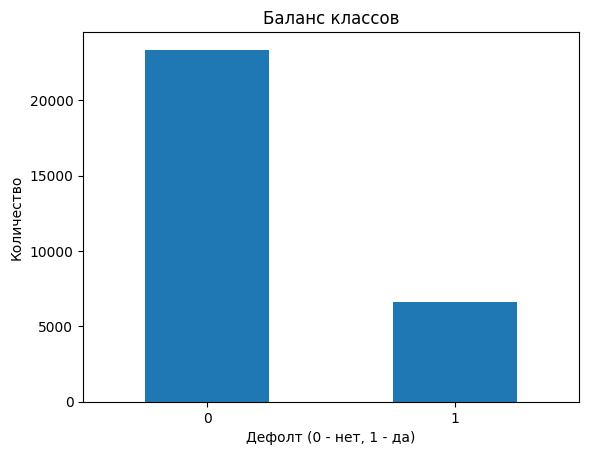

In [105]:
# График баланса классов:

df['default.payment.next.month'].value_counts().plot(kind='bar')  # столбчатая диаграмма
plt.title('Баланс классов')
plt.xlabel('Дефолт (0 - нет, 1 - да)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

In [106]:
pd.set_option('display.max_columns', None)  # показываем все колонки
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


- EDUCATION имеет значения 0 которые не описаны в документации, это аномалии
- MARRIAGE имеет значение 0 которое тоже не описано
- BILL_AMT имеет отрицательные значения, это, возможно, переплаты

In [107]:
# Проверю  аномальные значения в категориальных признаках:
print(df['EDUCATION'].value_counts().sort_index())  # распределение по образованию

print('\n', df['MARRIAGE'].value_counts().sort_index())   # распределение по семейному положению

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

 MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [108]:
# Объединю эти аномальные значения с категорией "others":

df['EDUCATION'] = df['EDUCATION'].replace(0, 4)  # заменяем 0 на "others"
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)    # заменяем 0 на "others"

print(df['EDUCATION'].value_counts().sort_index())
print('\n', df['MARRIAGE'].value_counts().sort_index())

EDUCATION
1    10585
2    14030
3     4917
4      137
5      280
6       51
Name: count, dtype: int64

 MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [109]:
# Корреляция с целевой переменной:

correlations = df.corr()['default.payment.next.month'].sort_values(ascending=False)
print(correlations)


default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.026736
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.027575
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default.payment.nex

### Выводы:

- PAY_0-PAY_6 - самые важные признаки (история просрочек напрямую влияет на дефолт)
- LIMIT_BAL - чем больше кредитный лимит, тем меньше вероятность дефолта
- PAY_AMT - чем больше платежи, тем меньше вероятность дефолта
- BILL_AMT - слабая отрицательная корреляция
- ID - нужно удалить, это просто номер строки

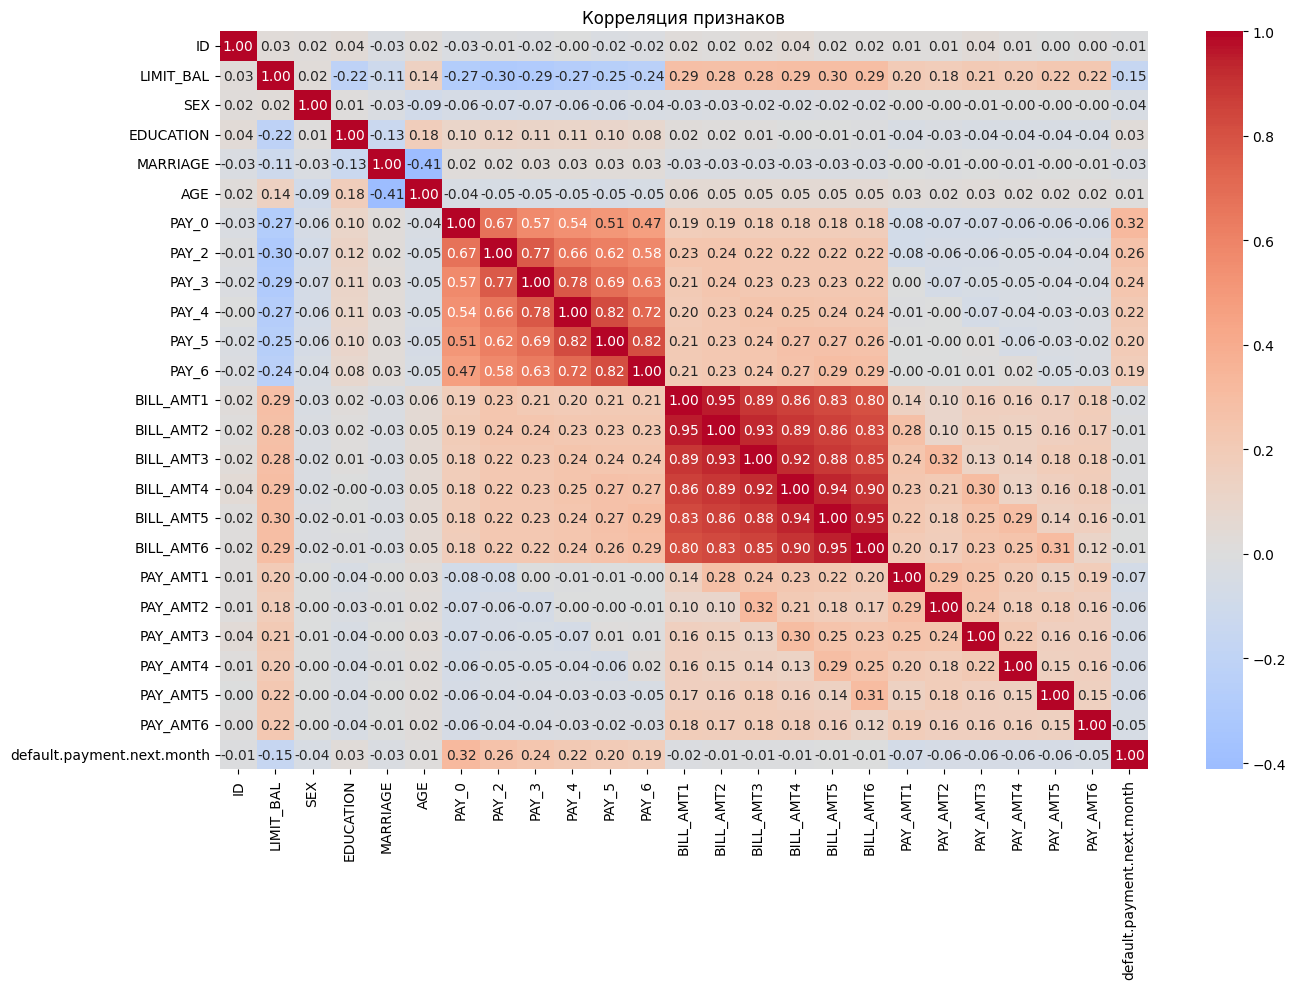

In [110]:
# Таблица корреляции (тепловая карта)

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')  
plt.title('Корреляция признаков')
plt.tight_layout()
plt.show()

In [111]:
# Удалю идентификатор и разобью данные на признаки и таргет

df = df.drop(columns=['ID'])  # удаляем ID

X = df.drop(columns=['default.payment.next.month'])  # признаки
y = df['default.payment.next.month']                 # таргет

print(X.shape, y.shape)

(30000, 23) (30000,)


In [112]:
# Разобью данные на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)  # 80/20
print(X_train.shape, X_test.shape)

(24000, 23) (6000, 23)


## 1. Организация кода и контроль версий (Git):
Создал структурированный репозиторий на GitHub (не использовал шаблон cookiecutter-data-science, сделал вручную).
Код должен быть хорошо организован в модули (папки src/, tests/, notebooks/, data/, models/ и так далее).

## 2. Обучение простой модели

Я выбрал LogisticRegression, так как она простая, быстрая и хорошо интерпретируема для задачи кредитного скоринга.

In [113]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=random_state)   # class_weight из-за дисбаланса классов
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81      4687
           1       0.39      0.57      0.47      1313

    accuracy                           0.71      6000
   macro avg       0.63      0.66      0.64      6000
weighted avg       0.76      0.71      0.73      6000



### Базовая модель показала:

- Класс 0 (нет дефолта): precision=0.86, recall=0.76, F1=0.81 - хорошо
- Класс 1 (дефолт): precision=0.39, recall=0.57, F1=0.47 - слабо
- Accuracy=0.71 - выглядит неплохо, но обманчива из-за дисбаланса классов
- Низкий precision класса 1 означает много ложных предсказаний дефолта (ошибка первого рода)
- Низкий recall класса 1 означает что пропускаем реальные дефолты (ошибка второго рода)
- Попробую улучшить через подбор гиперпараметра C

In [114]:
params = {'C': [0.01, 0.1, 1, 10, 100]}  # перебираем значения C

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    params,
    scoring='f1',  # оптимизируем по F1 класса 1
    cv=5           # 5-fold кросс-валидация
)
grid.fit(X_train, y_train)

print('Лучший C:', grid.best_params_)
print('Лучший F1:', grid.best_score_)

Лучший C: {'C': 1}
Лучший F1: 0.476859897639902


In [ ]:
# Попробую масштабировать данные 

pipeline = Pipeline([
    ('scaler', StandardScaler()),                                                    
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=random_state))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.71      0.78      4687
           1       0.38      0.65      0.48      1313

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.72      6000



### Результаты с масштабированием:

- Класс 1 (дефолт): recall вырос с 0.57 до 0.65, меньше пропускаем дефолтов
- Но precision упал с 0.39 до 0.38 - чуть больше ложных тревог
- F1 класса 1 вырос с 0.47 до 0.48 - небольшое улучшение

Для банка предпочтительнее ошибки первого рода, так как лучше потерять клиента, чем реальные деньги. Оставляем так.

### Сделаю на основе этих выводов файл для создания модели models/train_model.py